# Vertex Deviation Information
This notebok showcases the code used to create all the plots related to verteex deviation that are used in my poster for theUURIP24 poster event.

Full credit to Lusimi for the classes and functions used
in "functions". For more visit:
https://github.com/luismi98/astrophysics-research

## Vertex Deviation as a Function of Latitude

############################################## Read in data ############################################## 
Load RRLyr
Removed 1130 bad indices, leaving 6077 stars.


Load APOGEE
Found 13031 total stars.
Removed 2545 bad indices, leaving 10486 stars.


############################################## Spatial Cuts ############################################## 


############################################## Metallicity Cuts ##############################################
APOGEE
[Fe/H]$~>-0.21$ -0.2099115550518036 0.6065284609794617 1236
$-1<~$[Fe/H]/dex$~<-0.21$ -0.9998615980148315 -0.21020154654979706 1244
$-1.5<~$[Fe/H]/dex$~<-1$ -1.481561541557312 -1.0005615949630737 130


RRLyr
$-2.5<~$[Fe/H]/dex$~<-1$ -2.4503999018199387 -1.002407464319937 1487




############################################## Latitude Binning ##############################################
APOGEE
[Fe/H]$~>-0.21$
$-1<~$[Fe/H]/dex$~<-0.21$
$-1.5<~$[Fe/H]/dex$~<-1$


RRLyr
$-2.5<~$[Fe/H]/dex$~<-1$




################

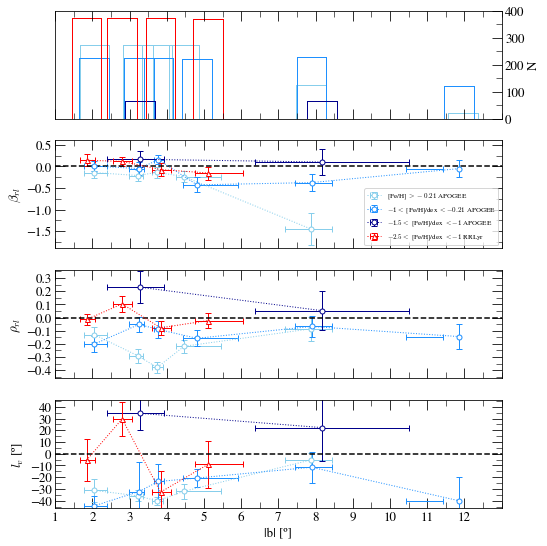

In [6]:
### BMcD 12/09/2024 - The following code plots anistropy, correlation, and vertex deviation (of vr-rl velocity ellipsoides) as a function of latitude
###                   The stars are first put into metallicity populations and then are binned into equal-number latitude bins  

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

import functions.compute_variables as CV
from functions.errorconfig import BootstrapConfig, MonteCarloConfig
import functions.montecarlo_errors as montecarlo
import functions.bootstrap_errors as bootstrap

import functions.miscellaneous_functions as MF
import functions.matplotlib_param_funcs as plot_param

import functions.load_data as load_data
import functions.load_RRLyr as load_RRLyr

plot_param.set_matplotlib_params()
bootstrapconfig = BootstrapConfig(from_mean=False,symmetric=True,repeats=5000)


def equal_number_binning(df, var, min, max, nbins):

    """
    This function takes some data and bins them into n equal-number bins
    e.g. stars to be binned into 4 equal-number bins over 1.4º<|b|<7º would need var"b", min=1.5, max=7, nbins=4

    Parameters
    ----------
    df: pandas dataframe 
    var: variable within df to bin
    min: minimum bin edge
    max: maximum bin edge
    nbins: number of bins

    Returns
    ------
    binned_data: list of length nbins with each element contained the binned data between the corresponding i, i+1 bin edges in bin_edges
    bin_edges: list of length nbins+1 contained the bin edges
    """

    bin_edges = [min] 
    binned_data = []

    data_to_bin = df[(min<=df[var])&(df[var]<=max)] ### get data between min and max variables of the set variable

    goal = round(len(data_to_bin)/nbins) ### find the number of stars each bin should have
    step = 0.001

    # for every bin
    for bin in range(nbins):

        # find the starting bin edge
        lower_edge = bin_edges[bin]

        bin_df = data_to_bin[lower_edge<=data_to_bin[var]]
        equal_cut_test = lower_edge

        # step through the bin range and count the number of stars 
        for pop in range(50000):
                middle_cut = bin_df[bin_df[var]<=equal_cut_test]

                count_test = len(middle_cut)

                if count_test >= goal: ### stop the step if the number of stars in the bin is equal to the same number of stars in all bins
                    break

                if equal_cut_test >= max: ### stop the step if the current bin edge is greater than the maximum edge
                    break

                equal_cut_test += step 

        upper_edge = equal_cut_test ### find the upper edge of the current bin

        bin_edges.append(upper_edge)

        b_bin_stars = bin_df[(lower_edge<=bin_df[var])&(bin_df[var]<+upper_edge)] # get the data between the lower and upper bin edge

        binned_data.append(b_bin_stars)

    return binned_data, bin_edges


def get_error(df,true_value,function,error_type,vel_x_var=None,vel_y_var=None,montecarloconfig=None,bootstrapconfig=None,tilt=False,absolute=False,R_hat=None):

    if error_type=="MC" and montecarloconfig is None:
        raise ValueError(f"Estimating MC errors but montecarloconfig was None.")
    if error_type=="bootstrap" and bootstrapconfig is None:
        raise ValueError(f"Estimating bootstrap errors but bootstrapconfig was None.")

    if vel_x_var is None and vel_y_var is None:
        raise ValueError("At least one of vel_x_var and vel_y_var must not be None.")

    if error_type == "bootstrap":

        vx,vy = None,None

        if vel_x_var is not None:
            vx = df["v"+vel_x_var].values
        if vel_y_var is not None:
            vy = df["v"+vel_y_var].values
        
        result = bootstrap.get_std_bootstrap(function=function, vx=vx, vy=vy, tilt=tilt, absolute=absolute, R_hat=R_hat,config=bootstrapconfig)

        return result.confidence_interval
    
    elif error_type == "MC":
        std_low,std_high,*_ = montecarlo.get_std_MC(df=df, true_value=true_value,function=function, montecarloconfig=montecarloconfig, vel_x_var=vel_x_var, vel_y_var=vel_y_var, \
                                         tilt=tilt, absolute=absolute, R_hat=R_hat)
        
        return std_low,std_high
    
    else:
        raise ValueError(f"Error type `{error_type}` not recognised.")


# slight changes have been amde to this function from Luismi's version
# although I am using dictionaries, I am not using them in the way Luismi has
# The function works to check if "full_map_string_list" is a calculation to be done, if so it shall calculate it along with its error
def get_all_variable_values_and_errors(df_vals,vel_x_var,vel_y_var,full_map_string_list,df_errors=None,montecarloconfig=None,bootstrapconfig=bootstrapconfig,\
                                       min_number=0, bin_surface=None, R_hat=None, x_var=None,y_var=None,error_type="bootstrap", lower=False, upper=False):
    
    """
    Create a dictionary with the values of all the variables in full_map_string_list.

    Parameters
    ----------
    df_vals : pandas DataFrame
        Data, observational or simulated, to compute the variables for.
    vel_x_var : str
        Suffix of x-component of velocity.
    vel_y_var : str
        Suffix of y-component of velocity.
    full_map_string_list : list of str
        List of statistics to compute (e.g., 'mean_vx', 'std_vx', 'n_density').
    df_errors : pandas DataFrame, optional
        Data previous to applying any cuts that affect the Monte Carlo error calculation.
        Defaults to None, in which case df_vals is used.
    montecarloconfig : MonteCarloConfig, optional
        Configuration for Monte Carlo error estimation. See src/errorconfig.py
        Required if error_type is 'MC'. Defaults to None.
    bootstrapconfig : BootstrapConfig, optional
        Configuration for bootstrap error estimation. See src/errorconfig.py
        Required if error_type is 'bootstrap'. Defaults to None.
    min_number : int, optional
        Minimum number of stars required to compute statistics. Defaults to 50.
    bin_surface : float, optional
        Surface area of each bin, required to calculate the number density. 
        Required if 'n_density' is in full_map_string_list. Defaults to None.
    R_hat : tuple, optional
        Radial distance, required for spherical tilt calculations. Defaults to None.
    x_var : str, optional
        Horizontal position variable, required for spherical tilt calculations. Defaults to None.
    y_var : str, optional
        Vertical position variable, required for spherical tilt calculations. Defaults to None.
    error_type : str, optional
        Type of error estimation to use ('bootstrap' or 'MC'). Defaults to 'bootstrap'.

    Returns
    -------
    map_dict : dict
        A dictionary with the values of all the variables in full_map_string_list.
    """
    
    if "spherical_tilt" in full_map_string_list and (x_var is None or y_var is None or R_hat is None):
        raise ValueError("Cannot compute spherical_tilt without R_hat, x_var and y_var.")
    if "n_density" in full_map_string_list and not bin_surface:
        raise ValueError("Cannot compute n_density without bin_surface.")
    if error_type == "MC":
        if montecarloconfig is None:
            raise ValueError("The MC config needs to be passed when error_type is MC, but it was None.")
        elif df_errors is None:
            raise ValueError("df_errors needs to be passed when error_type is MC, but it was None.")
        elif len(df_errors) == len(df_vals) and np.all(df_errors == df_vals): # need the length check otherwise element-to-element comparison fails
            print("The dataframe for values and errors were identical.")
    elif error_type == "bootstrap":
        if bootstrapconfig is None:
            raise ValueError("The bootstrap config needs to be passed when error_type is bootstrap, but it was None.")
    if error_type != "MC" and df_errors is not None and np.any(df_errors != df_vals):
        raise ValueError(f"The dataframe for values and errors should be the same when estimating the latter using `{error_type}`.")

    if df_errors is None:
        df_errors = df_vals

    vx,vy = df_vals["v"+vel_x_var].values, df_vals["v"+vel_y_var].values

    map_dict = {}

    number = len(vx)

    if "number" in full_map_string_list:
        map_dict["number"] = number
    
    if "n_density" in full_map_string_list:
        n_density = number/bin_surface
        map_dict["n_density"] = n_density
    
    if number < min_number:
        print(f"Found `{number}` stars, less than the min of `{min_number}`")
        for variable in full_map_string_list:
            if variable != "number" and variable != "n_density":
                map_dict[variable] = np.nan 
        return map_dict

    common_error_args = {
        "df": df_errors,
        "error_type": error_type,
        "montecarloconfig": montecarloconfig,
        "bootstrapconfig": bootstrapconfig
    }
    
    if full_map_string_list == "mean_vx":
        calc = np.mean(vx)
        low, high = get_error(true_value=None,function=np.mean,vel_x_var=vel_x_var,**common_error_args)
    
    if full_map_string_list == "mean_vy":
        calc = np.mean(vy)
        low, high = get_error(true_value=None,function=np.mean,vel_y_var=vel_y_var,**common_error_args)

    if full_map_string_list == "std_vx":
        calc = np.std(vx)
        low, high = get_error(true_value=None,function=np.std,vel_x_var=vel_x_var,**common_error_args)

    if full_map_string_list == "std_vy":
        calc = np.std(vy)
        low, high = get_error(true_value=None,function=np.std,vel_y_var=vel_y_var,**common_error_args)
    
    if full_map_string_list == 'anisotropy':
        calc = CV.calculate_anisotropy(vx=vx,vy=vy)
        low, high = get_error(true_value=None,function=CV.calculate_anisotropy,vel_x_var=vel_x_var,vel_y_var=vel_y_var,**common_error_args)


    if  full_map_string_list == "correlation":
        calc = CV.calculate_correlation(vx=vx,vy=vy)
        low, high = get_error(true_value=None,function=CV.calculate_correlation,vel_x_var=vel_x_var,vel_y_var=vel_y_var,**common_error_args)
    
    if full_map_string_list == "tilt_abs":
        calc = CV.calculate_tilt(vx=vx,vy=vy,absolute=True)
        low, high = get_error(true_value=None,function=CV.calculate_tilt,vel_x_var=vel_x_var,vel_y_var=vel_y_var,tilt=True,absolute=True,**common_error_args)
    
    if "spherical_tilt" in full_map_string_list:
        vx_s,vy_s = df_vals["v"+x_var].values, df_vals["v"+y_var].values

        map_dict["spherical_tilt"] = CV.calculate_spherical_tilt(vx_s,vy_s,R_hat,absolute=False)
        map_dict["spherical_tilt_error_low"],map_dict["spherical_tilt_error_high"] =\
              get_error(true_value=map_dict["spherical_tilt"],function=CV.calculate_spherical_tilt,vel_x_var=x_var,vel_y_var=y_var,tilt=True,absolute=False,R_hat=R_hat, **common_error_args)

    if "abs_spherical_tilt" in full_map_string_list:
        map_dict["abs_spherical_tilt"] = abs(map_dict["spherical_tilt"])
        map_dict["abs_spherical_tilt_error_low"],map_dict["abs_spherical_tilt_error_high"] =\
              get_error(true_value=map_dict["abs_spherical_tilt"],function=CV.calculate_spherical_tilt,vel_x_var=x_var,vel_y_var=y_var,absolute=True,R_hat=R_hat, **common_error_args)

    if "tilt" in full_map_string_list:
        map_dict["tilt"] = CV.calculate_tilt(vx=vx,vy=vy,absolute=False)
        map_dict["tilt_error"] = get_error(true_value=map_dict["tilt"],function=CV.calculate_tilt, vel_x_var=vel_x_var,vel_y_var=vel_y_var, tilt=True,absolute=False, **common_error_args)        

    return calc, low, high


R0 = 8.1
Z0 = 0
obs_errors = False
GSR=True
zabs = True 

############################################## Read in data ############################################## 

print('############################################## Read in data ############################################## ')

print('Load RRLyr')
RRLyr_data = load_RRLyr.load_RRLyr_data('../data/RRLyr-6D.csv')
print('\n')
print('Load APOGEE')
APOGEE_d = load_data.load_and_process_data(data_path='../../data/observations/', error_bool=obs_errors, zabs=zabs, R0=R0, GSR=GSR)

print('\n')

############################################## Spatial Cuts ############################################## 

print('############################################## Spatial Cuts ############################################## ')

# set spatial cuts 
x_variable = "l"
y_variable = "b"

extra_variable = "R"

xmin = -2
xmax = 2

ymin = 1.5
ymax = 13

dmin=5
dmax=11

extra_min = 0
extra_max = 3.5

xymax = 3.5
zmax = 3

# metallciity cuts - takes RR Lyrae stars of [Fe/H]=[-2.5, -1] and APOGEEstars of [Fe/H]=[-1.5, inf)
RRLyr_spatial = RRLyr_data[(RRLyr_data[x_variable]>=xmin)&(RRLyr_data[x_variable]<=xmax)&(RRLyr_data[y_variable]>=ymin)&(RRLyr_data[y_variable]<=ymax)&(RRLyr_data[extra_variable]>=extra_min)&(RRLyr_data[extra_variable]<extra_max)&(-2.5<=RRLyr_data['FeH'])&(RRLyr_data['FeH']<=-1)]

APOGEE_spatial = APOGEE_d[(APOGEE_d[x_variable]>=xmin)&(APOGEE_d[x_variable]<=xmax)&(APOGEE_d[y_variable]>=ymin)&(APOGEE_d[y_variable]<=ymax)&(APOGEE_d[extra_variable]>=extra_min)&(APOGEE_d[extra_variable]<extra_max)&(-1.5<=APOGEE_d['FeH'])]

print('\n')

############################################## Metallicity Cuts ############################################## 

print('############################################## Metallicity Cuts ##############################################')

luismi_metal_trim = -1

APOGEE_metal_trim = APOGEE_d[luismi_metal_trim<=APOGEE_d['FeH']]

RRLyr_metal_trim = RRLyr_data[-4<=RRLyr_data['FeH']]

APOGEE_metallicity_median = MF.return_int_or_dec(np.median(APOGEE_metal_trim["FeH"]),2)

# Metallicity population limits
metal_cut_dict = {
    'APOGEE': {'most_poor_lowerlim': -1.5,
             'most_poor_higherlim': luismi_metal_trim,
             'poor_lowerlim': luismi_metal_trim,
             'poor_higherlim': APOGEE_metallicity_median,
             'rich_lowerlim': APOGEE_metallicity_median,
             'rich_higherlim': None
              },

    'RRLyr': {'lowerlim': -2.5,
              'higherlim': -1,
             }
}

metal_label_dict = {
    'APOGEE': {},

    'RRLyr': {}
}

metal_data_dict = {
    'APOGEE': {},

    'RRLyr': {}
}

# seperates the data into the corressponding metallicity populations
for dataset in metal_cut_dict:  

    if dataset == 'APOGEE':

        if metal_cut_dict[dataset]['rich_higherlim'] is None:
            rich_condition = APOGEE_spatial["FeH"] >= metal_cut_dict[dataset]['rich_lowerlim']
            low = metal_cut_dict[dataset]['rich_lowerlim']
            label_rich = fr'[Fe/H]$~>{str(low)}$'
        else:
            rich_condition = (APOGEE_spatial["FeH"] <= metal_cut_dict[dataset]['rich_higherlim'])&(APOGEE_spatial["FeH"] >= metal_cut_dict[dataset]['rich_lowerlim'])
            low = metal_cut_dict[dataset]['rich_lowerlim']
            high = metal_cut_dict[dataset]['rich_higherlim']
            label_rich = fr'${str(low)}<~$[Fe/H]/dex$~<{str(high)}$'

        if metal_cut_dict[dataset]['poor_lowerlim'] is None:
            poor_condition = APOGEE_spatial["FeH"] < metal_cut_dict[dataset]['poor_higherlim']
            high = metal_cut_dict[dataset]['poor_higherlim']
            label_poor = fr'[Fe/H]$~<{str(high)}$'
        else:
            poor_condition = (APOGEE_spatial["FeH"] < metal_cut_dict[dataset]['poor_higherlim'])&(APOGEE_spatial["FeH"] > metal_cut_dict[dataset]['poor_lowerlim'])
            low = metal_cut_dict[dataset]['poor_lowerlim']
            high = metal_cut_dict[dataset]['poor_higherlim']
            label_poor = fr'${str(low)}<~$[Fe/H]/dex$~<{str(high)}$'

        if metal_cut_dict[dataset]['most_poor_lowerlim'] is None:
            most_poor_condition = APOGEE_spatial["FeH"] < metal_cut_dict[dataset]['most_poor_higherlim']
            high = metal_cut_dict[dataset]['most_poor_higherlim']
            label_most_poor = fr'[Fe/H]$~<{str(high)}$'
        else:
            most_poor_condition = (APOGEE_spatial["FeH"] < metal_cut_dict[dataset]['most_poor_higherlim'])&(APOGEE_spatial["FeH"] > metal_cut_dict[dataset]['most_poor_lowerlim'])
            low = metal_cut_dict[dataset]['most_poor_lowerlim']
            high = metal_cut_dict[dataset]['most_poor_higherlim']
            label_most_poor = fr'${str(low)}<~$[Fe/H]/dex$~<{str(high)}$'

        metal_data_dict[dataset].update({label_rich: APOGEE_spatial[rich_condition], label_poor:APOGEE_spatial[poor_condition], label_most_poor: APOGEE_spatial[most_poor_condition]})
        metal_label_dict[dataset].update({label_rich:label_rich, label_poor: label_poor, label_most_poor: label_most_poor})
    
    if dataset=='RRLyr':
        RRLyr_condition = (metal_cut_dict[dataset]['lowerlim']<=RRLyr_spatial['FeH'])&(RRLyr_spatial['FeH']<=metal_cut_dict[dataset]['higherlim'])
        low = metal_cut_dict[dataset]['lowerlim']
        high = metal_cut_dict[dataset]['higherlim']
        RRLyr_label = fr'${str(low)}<~$[Fe/H]/dex$~<{str(high)}$'

        metal_data_dict[dataset].update({RRLyr_label:RRLyr_spatial[RRLyr_condition]})
        metal_label_dict[dataset].update({RRLyr_label:RRLyr_label})

# checks the metallicity populations have the correct limits
for dataset in metal_data_dict:
    print(dataset)
    for pop in metal_data_dict[dataset]:
        print(metal_label_dict[dataset][pop], metal_data_dict[dataset][pop]['FeH'].min(), metal_data_dict[dataset][pop]['FeH'].max(), len(metal_data_dict[dataset][pop]))

    print('\n')

print('\n')

############################################## Latitude Binning ############################################## 

print('############################################## Latitude Binning ##############################################')

gross_bin_cuts = [ymin, 7, 9, 11, 13]
bin_data = []
equal_bin_edge = []

metal_bin_edges_dict = {
    'APOGEE': {},

    'RRLyr': {}
}

metal_binned_data_dict = {
    'APOGEE': {},

    'RRLyr': {}
}

# bin by latitude
for row, dataset in enumerate(metal_data_dict):

    print(dataset)

    for col, df_metal in enumerate(metal_data_dict[dataset]):

        data = metal_data_dict[dataset][df_metal]

        if metal_label_dict[dataset][df_metal] ==list(metal_label_dict['APOGEE'].keys())[-1]:
            equal_bin_data, equal_lat_edges = equal_number_binning(data, y_variable, ymin, 13, 2) ### seperates the most metal-poor population into two latitude bins due to low star numbers
        else:
            equal_bin_data, equal_lat_edges = equal_number_binning(data, y_variable, ymin, 7, 4) ### seperates the |b|<7º region into 4 equal-number latitude bins

        # includes two more latitude bins corresponding to the "blobs" see at |b|=8º, 12º (only applies for APOGEE data)
        if dataset == "APOGEE" and metal_label_dict[dataset][df_metal] != list(metal_label_dict['APOGEE'].keys())[-1]:

            equal_lat_edges.append(9)
            equal_lat_edges.append(11)
            equal_lat_edges.append(ymax)

            b8_bin = data[(7<=data[y_variable])&(data[y_variable]<=9)]
            equal_bin_data.append(b8_bin)
            b12_bin = data[(11<=data[y_variable])&(data[y_variable]<=ymax)]
            equal_bin_data.append(b12_bin)

        print(metal_label_dict[dataset][df_metal])

        metal_bin_edges_dict[dataset].update({metal_label_dict[dataset][df_metal]:equal_lat_edges})
        metal_binned_data_dict[dataset].update({metal_label_dict[dataset][df_metal]:equal_bin_data})
    print('\n')

# Binning plot to visualise that the binning is correct
if False:
    clr = ['brown', 'orange', 'purple', 'olive', 'k', 'b', 'g', 'r']

    fig = plt.figure()

    for row, dataset in enumerate(metal_data_dict):

        for col, df_metal in enumerate(metal_data_dict[dataset]):

            ax = plt.subplot2grid((2,2*len(metal_data_dict[dataset])), (row,2*col), colspan=2)

            if col==0:
                ax.set_ylabel(r'|b| [º]')

            if col > 0:
                ax.set_yticklabels([])

            for bin, lat_bin in enumerate(metal_binned_data_dict[dataset][df_metal]):

                count=len(lat_bin)

                ax.scatter(lat_bin['l'], lat_bin['b'], c=clr[bin] if count>=50 else 'grey', s=1, alpha=0.5)

                x_pos = (lat_bin['l'].min()+lat_bin['l'].max())/2
                y_pos = (lat_bin['b'].min()+lat_bin['b'].max())/2

                ax.text(x=x_pos,y=y_pos,s=count,size=10, weight="bold",zorder=20, color="k")

                ax.set_xlabel(r'l [º]')
                ax.set_title(metal_label_dict[dataset][df_metal])

                for line in metal_bin_edges_dict[dataset][df_metal]:
                    ax.axhline(line, c='k', ls='--')

    plt.tight_layout()
    fig.subplots_adjust(wspace=0)
    #plt.savefig('plots/vertex_deviation_info/gaia_RRLyr_seperate/ani_corr_tilt/lat_binning/seperate_single_RRLyr_feh_lat_binning.pdf')
    #plt.show()



print('\n')

############################################## Calculations ############################################## 
print('############################################## Calculations ############################################## ')

### Values

calc_dict = {
    'APOGEE': {},

    'RRLyr': {}
}

err_dict = {
    'APOGEE': {},

    'RRLyr': {}
}

vel_x_var='r'
vel_y_var='l'

vx,vy = "v"+vel_x_var, "v"+vel_y_var

calc_param = ['anisotropy', "correlation", "tilt_abs"]


for ds_point, dataset in enumerate(metal_binned_data_dict):
    print(dataset)

    for metal_point, df_metal in enumerate(metal_binned_data_dict[dataset]):
        print(df_metal)

        calc_dict[dataset].update({df_metal:{}})
        err_dict[dataset].update({df_metal:{}})

        # other parameters that are not in calc_param
        count_array =  np.zeros(len(metal_binned_data_dict[dataset][df_metal]))
        x_array =  np.zeros(len(metal_binned_data_dict[dataset][df_metal]))
        x_error_array = np.zeros((2, len(metal_binned_data_dict[dataset][df_metal])))

        for param in calc_param:
            calc_dict[dataset][df_metal].update({param:{}})
            err_dict[dataset][df_metal].update({param:{}})

            # create an array for the calculations and their error
            calc_array = np.zeros(len(metal_binned_data_dict[dataset][df_metal]))
            error_array = np.zeros((2, len(metal_binned_data_dict[dataset][df_metal])))

            for ind, lat in enumerate(metal_binned_data_dict[dataset][df_metal]):
                count_array[ind] = len(lat)
                x_array[ind] = np.median(lat['b'])

                # the error in latitude is half the legnth between the median of the bin and the bin's edge
                lower = metal_bin_edges_dict[dataset][df_metal][ind]
                upper = metal_bin_edges_dict[dataset][df_metal][ind+1]
                x_error_array[0, ind] = (x_array[ind]-lower)/2
                x_error_array[1, ind] = (upper-x_array[ind])/2

                calc_array[ind], error_array[0, ind], error_array[1, ind] = get_all_variable_values_and_errors(df_vals=lat, full_map_string_list=param, vel_x_var=vel_x_var, vel_y_var=vel_y_var, error_type='bootstrap', bootstrapconfig=bootstrapconfig)

            # add data to latitude dictionary 
            calc_dict[dataset][df_metal].update({param:calc_array})
            err_dict[dataset][df_metal].update({param:error_array})
            err_dict[dataset][df_metal].update({'x':x_error_array})
            calc_dict[dataset][df_metal].update({'x':x_array})
            calc_dict[dataset][df_metal].update({'count':count_array})
            



aspect_ratio = 1 + zmax/(2*xymax)    
fsize = 8

fig,axs=plt.subplots(figsize=(fsize,aspect_ratio*fsize*0.8),nrows=4,sharex=True)#,gridspec_kw={"hspace":0})

color = ['skyblue', 'dodgerblue', 'darkblue', 'red']
marker = ['o', 'o', 'o', '^', '^']

for dataset in calc_dict:

    for clr, df_metal in enumerate(calc_dict[dataset]):

        if dataset == 'RRLyr':
            clr+=len(calc_dict['APOGEE'])

        for row, prop in enumerate(calc_param, 1):

            for index, nstar in enumerate(calc_dict[dataset][df_metal]['count']):
                if nstar < 50 : 
                    calc_dict[dataset][df_metal][prop][index]=np.nan
                    err_dict[dataset][df_metal][prop][:, index]=np.nan

            axs[0].bar(calc_dict[dataset][df_metal]['x'], calc_dict[dataset][df_metal]['count'], fill=False, edgecolor=color[clr])

            axs[row].errorbar(calc_dict[dataset][df_metal]['x'], calc_dict[dataset][df_metal][prop], xerr=err_dict[dataset][df_metal]['x'], yerr=err_dict[dataset][df_metal][prop], c=color[clr], mfc='w', ms=5, marker=marker[clr], capsize=3, ls=':', label=metal_label_dict[dataset][df_metal]+' '+dataset, lw=1)

# Plotting cosmetics     
axs[1].legend()

axs[0].set_yticks(np.arange(0, calc_dict[dataset][df_metal]['count'].max()+50, 100))
axs[0].yaxis.set_minor_locator(MultipleLocator(50))
axs[0].yaxis.tick_right()
axs[0].set_ylabel('N')
axs[0].yaxis.set_label_position("right")

axs[1].axhline(0, ls='--', c='k')
axs[2].axhline(0, ls='--', c='k')
axs[3].axhline(0, ls='--', c='k')

axs[1].set_yticks(np.arange(-2.5, 1.5, 0.5))
axs[1].yaxis.set_minor_locator(MultipleLocator(0.25))
axs[1].set_ylim(-1.9, 0.6)
axs[1].set_ylabel(r'$\beta_{'+vel_x_var+''+vel_y_var+'}$')

axs[2].set_yticks(np.arange(-0.4, 0.4, 0.1))
axs[2].yaxis.set_minor_locator(MultipleLocator(0.05))
axs[2].set_ylim(-0.46, 0.36)
axs[2].set_ylabel(r'$\rho_{'+vel_x_var+''+vel_y_var+'}$')

axs[3].set_yticks(np.arange(-40, 50, 10))
axs[3].yaxis.set_minor_locator(MultipleLocator(5))
axs[3].set_ylim(-46, 46)
axs[3].set_ylabel(r'$l_v$ [º]')

axs[1].legend(fontsize=7)

axs[3].set_xticks(np.arange(0, 13, 1))
axs[3].xaxis.set_minor_locator(MultipleLocator(0.5))
axs[3].set_xlim(1, 13)
axs[3].set_xlabel('|b| [º]')

#plt.savefig('plots/vertex_deviation_info/gaia_RRLyr_seperate/ani_corr_tilt/seperate_single_RRLyr_ani_corr_tilt.pdf')
plt.show()

## Kinematic Information as a Function of Metallicity

############################################## Read in data ############################################## 
Load RRLyr
Removed 1130 bad indices, leaving 6077 stars.


Load APOGEE
Found 13031 total stars.
Removed 2545 bad indices, leaving 10486 stars.


############################################## Spatial Cuts ############################################## 
############################################## Binning ##############################################
APOGEE
1.5º<|b|<3.51º
3.51º<|b|<6.6º
7.13º<|b|<8.85º
11º<|b|<13º
RRLyr
1.5º<|b|<3.51º
3.51º<|b|<6.6º
7.13º<|b|<8.85º
11º<|b|<13º


############################################## Calculations ############################################## 
APOGEE
1.5º<|b|<3.51º
3.51º<|b|<6.6º
7.13º<|b|<8.85º
11º<|b|<13º
RRLyr
1.5º<|b|<3.51º
3.51º<|b|<6.6º


############################################## Plotting ############################################## 
APOGEE
1.5º<|b|<3.51º
3.51º<|b|<6.6º
7.13º<|b|<8.85º
11º<|b|<13º
RRLyr
1.5º<|b|<3.51º
3.51º

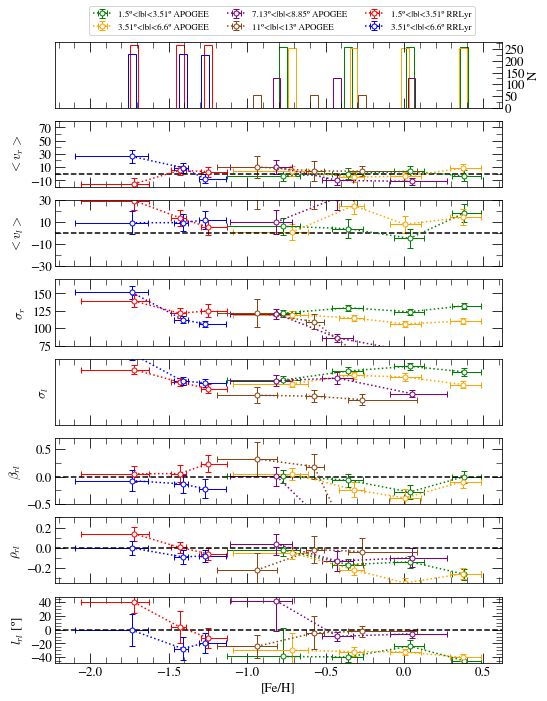

In [7]:
### BMcD 12/09/2024 - This code plots the kinemaatics information of APOGEE adn RR Lyrae stas as a function of metallicity
###                   The stars are seperated into latitude bins first and then binned into equal-number metallicity bins for each latitude

import pandas as pd
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

import functions.compute_variables as CV
from functions.errorconfig import BootstrapConfig, MonteCarloConfig
import functions.montecarlo_errors as montecarlo
import functions.bootstrap_errors as bootstrap

import functions.miscellaneous_functions as MF
import functions.mixed_plots as MP
import functions.matplotlib_param_funcs as plot_param

import functions.load_data as load_data
import functions.load_RRLyr as load_RRLyr

plot_param.set_matplotlib_params()
bootstrapconfig = BootstrapConfig(from_mean=False,symmetric=True,repeats=5000)


def equal_number_binning(df, var, min, max, nbins):

    """
    This function takes some data and bins them into n equal-number bins
    e.g. stars to be binned into 4 equal-number bins over 1.4º<|b|<7º would need var"b", min=1.5, max=7, nbins=4

    Parameters
    ----------
    df: pandas dataframe 
    var: variable within df to bin
    min: minimum bin edge
    max: maximum bin edge
    nbins: number of bins

    Returns
    ------
    binned_data: list of length nbins with each element contained the binned data between the corresponding i, i+1 bin edges in bin_edges
    bin_edges: list of length nbins+1 contained the bin edges
    """

    bin_edges = [min] 
    binned_data = []

    data_to_bin = df[(min<=df[var])&(df[var]<=max)] ### get data between min and max variables of the set variable

    goal = round(len(data_to_bin)/nbins) ### find the number of stars each bin should have
    step = 0.001

    # for every bin
    for bin in range(nbins):

        # find the starting bin edge
        lower_edge = bin_edges[bin]

        bin_df = data_to_bin[lower_edge<=data_to_bin[var]]
        equal_cut_test = lower_edge

        # step through the bin range and count the number of stars 
        for pop in range(50000):
                middle_cut = bin_df[bin_df[var]<=equal_cut_test]

                count_test = len(middle_cut)

                if count_test >= goal: ### stop the step if the number of stars in the bin is equal to the same number of stars in all bins
                    break

                if equal_cut_test >= max: ### stop the step if the current bin edge is greater than the maximum edge
                    break

                equal_cut_test += step 

        upper_edge = equal_cut_test ### find the upper edge of the current bin

        bin_edges.append(upper_edge)

        b_bin_stars = bin_df[(lower_edge<=bin_df[var])&(bin_df[var]<+upper_edge)] # get the data between the lower and upper bin edge

        binned_data.append(b_bin_stars)

    return binned_data, bin_edges


def get_error(df,true_value,function,error_type,vel_x_var=None,vel_y_var=None,montecarloconfig=None,bootstrapconfig=None,tilt=False,absolute=False,R_hat=None):

    if error_type=="MC" and montecarloconfig is None:
        raise ValueError(f"Estimating MC errors but montecarloconfig was None.")
    if error_type=="bootstrap" and bootstrapconfig is None:
        raise ValueError(f"Estimating bootstrap errors but bootstrapconfig was None.")

    if vel_x_var is None and vel_y_var is None:
        raise ValueError("At least one of vel_x_var and vel_y_var must not be None.")

    if error_type == "bootstrap":

        vx,vy = None,None

        if vel_x_var is not None:
            vx = df["v"+vel_x_var].values
        if vel_y_var is not None:
            vy = df["v"+vel_y_var].values
        
        result = bootstrap.get_std_bootstrap(function=function, vx=vx, vy=vy, tilt=tilt, absolute=absolute, R_hat=R_hat,config=bootstrapconfig)

        return result.confidence_interval
    
    elif error_type == "MC":
        std_low,std_high,*_ = montecarlo.get_std_MC(df=df, true_value=true_value,function=function, montecarloconfig=montecarloconfig, vel_x_var=vel_x_var, vel_y_var=vel_y_var, \
                                         tilt=tilt, absolute=absolute, R_hat=R_hat)
        
        return std_low,std_high
    
    else:
        raise ValueError(f"Error type `{error_type}` not recognised.")


# slight changes have been amde to this function from Luismi's version
# although I am using dictionaries, I am not using them in the way Luismi has
# The function works to check if "full_map_string_list" is a calculation to be done, if so it shall calculate it along with its error
def get_all_variable_values_and_errors(df_vals,vel_x_var,vel_y_var,full_map_string_list,df_errors=None,montecarloconfig=None,bootstrapconfig=bootstrapconfig,\
                                       min_number=0, bin_surface=None, R_hat=None, x_var=None,y_var=None,error_type="bootstrap", lower=False, upper=False):
    
    """
    Create a dictionary with the values of all the variables in full_map_string_list.

    Parameters
    ----------
    df_vals : pandas DataFrame
        Data, observational or simulated, to compute the variables for.
    vel_x_var : str
        Suffix of x-component of velocity.
    vel_y_var : str
        Suffix of y-component of velocity.
    full_map_string_list : list of str
        List of statistics to compute (e.g., 'mean_vx', 'std_vx', 'n_density').
    df_errors : pandas DataFrame, optional
        Data previous to applying any cuts that affect the Monte Carlo error calculation.
        Defaults to None, in which case df_vals is used.
    montecarloconfig : MonteCarloConfig, optional
        Configuration for Monte Carlo error estimation. See src/errorconfig.py
        Required if error_type is 'MC'. Defaults to None.
    bootstrapconfig : BootstrapConfig, optional
        Configuration for bootstrap error estimation. See src/errorconfig.py
        Required if error_type is 'bootstrap'. Defaults to None.
    min_number : int, optional
        Minimum number of stars required to compute statistics. Defaults to 50.
    bin_surface : float, optional
        Surface area of each bin, required to calculate the number density. 
        Required if 'n_density' is in full_map_string_list. Defaults to None.
    R_hat : tuple, optional
        Radial distance, required for spherical tilt calculations. Defaults to None.
    x_var : str, optional
        Horizontal position variable, required for spherical tilt calculations. Defaults to None.
    y_var : str, optional
        Vertical position variable, required for spherical tilt calculations. Defaults to None.
    error_type : str, optional
        Type of error estimation to use ('bootstrap' or 'MC'). Defaults to 'bootstrap'.

    Returns
    -------
    map_dict : dict
        A dictionary with the values of all the variables in full_map_string_list.
    """
    
    if "spherical_tilt" in full_map_string_list and (x_var is None or y_var is None or R_hat is None):
        raise ValueError("Cannot compute spherical_tilt without R_hat, x_var and y_var.")
    if "n_density" in full_map_string_list and not bin_surface:
        raise ValueError("Cannot compute n_density without bin_surface.")
    if error_type == "MC":
        if montecarloconfig is None:
            raise ValueError("The MC config needs to be passed when error_type is MC, but it was None.")
        elif df_errors is None:
            raise ValueError("df_errors needs to be passed when error_type is MC, but it was None.")
        elif len(df_errors) == len(df_vals) and np.all(df_errors == df_vals): # need the length check otherwise element-to-element comparison fails
            print("The dataframe for values and errors were identical.")
    elif error_type == "bootstrap":
        if bootstrapconfig is None:
            raise ValueError("The bootstrap config needs to be passed when error_type is bootstrap, but it was None.")
    if error_type != "MC" and df_errors is not None and np.any(df_errors != df_vals):
        raise ValueError(f"The dataframe for values and errors should be the same when estimating the latter using `{error_type}`.")

    if df_errors is None:
        df_errors = df_vals

    vx,vy = df_vals["v"+vel_x_var].values, df_vals["v"+vel_y_var].values

    map_dict = {}

    number = len(vx)

    if "number" in full_map_string_list:
        map_dict["number"] = number
    
    if "n_density" in full_map_string_list:
        n_density = number/bin_surface
        map_dict["n_density"] = n_density
    
    if number < min_number:
        print(f"Found `{number}` stars, less than the min of `{min_number}`")
        for variable in full_map_string_list:
            if variable != "number" and variable != "n_density":
                map_dict[variable] = np.nan 
        return map_dict

    common_error_args = {
        "df": df_errors,
        "error_type": error_type,
        "montecarloconfig": montecarloconfig,
        "bootstrapconfig": bootstrapconfig
    }
    
    if full_map_string_list == "mean_vx":
        calc = np.mean(vx)
        low, high = get_error(true_value=None,function=np.mean,vel_x_var=vel_x_var,**common_error_args)
    
    if full_map_string_list == "mean_vy":
        calc = np.mean(vy)
        low, high = get_error(true_value=None,function=np.mean,vel_y_var=vel_y_var,**common_error_args)

    if full_map_string_list == "std_vx":
        calc = np.std(vx)
        low, high = get_error(true_value=None,function=np.std,vel_x_var=vel_x_var,**common_error_args)

    if full_map_string_list == "std_vy":
        calc = np.std(vy)
        low, high = get_error(true_value=None,function=np.std,vel_y_var=vel_y_var,**common_error_args)
    
    if full_map_string_list == 'anisotropy':
        calc = CV.calculate_anisotropy(vx=vx,vy=vy)
        low, high = get_error(true_value=None,function=CV.calculate_anisotropy,vel_x_var=vel_x_var,vel_y_var=vel_y_var,**common_error_args)


    if  full_map_string_list == "correlation":
        calc = CV.calculate_correlation(vx=vx,vy=vy)
        low, high = get_error(true_value=None,function=CV.calculate_correlation,vel_x_var=vel_x_var,vel_y_var=vel_y_var,**common_error_args)
    
    if full_map_string_list == "tilt_abs":
        calc = CV.calculate_tilt(vx=vx,vy=vy,absolute=True)
        low, high = get_error(true_value=None,function=CV.calculate_tilt,vel_x_var=vel_x_var,vel_y_var=vel_y_var,tilt=True,absolute=True,**common_error_args)
    
    if "spherical_tilt" in full_map_string_list:
        vx_s,vy_s = df_vals["v"+x_var].values, df_vals["v"+y_var].values

        map_dict["spherical_tilt"] = CV.calculate_spherical_tilt(vx_s,vy_s,R_hat,absolute=False)
        map_dict["spherical_tilt_error_low"],map_dict["spherical_tilt_error_high"] =\
              get_error(true_value=map_dict["spherical_tilt"],function=CV.calculate_spherical_tilt,vel_x_var=x_var,vel_y_var=y_var,tilt=True,absolute=False,R_hat=R_hat, **common_error_args)

    if "abs_spherical_tilt" in full_map_string_list:
        map_dict["abs_spherical_tilt"] = abs(map_dict["spherical_tilt"])
        map_dict["abs_spherical_tilt_error_low"],map_dict["abs_spherical_tilt_error_high"] =\
              get_error(true_value=map_dict["abs_spherical_tilt"],function=CV.calculate_spherical_tilt,vel_x_var=x_var,vel_y_var=y_var,absolute=True,R_hat=R_hat, **common_error_args)

    if "tilt" in full_map_string_list:
        map_dict["tilt"] = CV.calculate_tilt(vx=vx,vy=vy,absolute=False)
        map_dict["tilt_error"] = get_error(true_value=map_dict["tilt"],function=CV.calculate_tilt, vel_x_var=vel_x_var,vel_y_var=vel_y_var, tilt=True,absolute=False, **common_error_args)        

    return calc, low, high


R0 = 8.1
Z0 = 0
obs_errors = False
GSR=True
zabs = True 

############################################## Read in data ############################################## 

print('############################################## Read in data ############################################## ')

print('Load RRLyr')
RRLyr_data = load_RRLyr.load_RRLyr_data('../data/RRLyr-6D.csv')
print('\n')
print('Load APOGEE')
APOGEE_d = load_data.load_and_process_data(data_path='../../data/observations/', error_bool=obs_errors, zabs=zabs, R0=R0, GSR=GSR)

print('\n')

############################################## Spatial Cuts ############################################## 

print('############################################## Spatial Cuts ############################################## ')

# set spatial cuts 
x_variable = "l"
y_variable = "b"

extra_variable = "R"

xmin = -2
xmax = 2

ymin = 1.5
ymax = 13

dmin=5
dmax=11

extra_min = 0
extra_max = 3.5

xymax = 3.5
zmax = 3

# metallciity cuts - takes RR Lyrae stars of [Fe/H]=[-2.5, -1] and APOGEEstars of [Fe/H]=[-1.5, inf)
RRLyr_spatial = RRLyr_data[(RRLyr_data[x_variable]>=xmin)&(RRLyr_data[x_variable]<=xmax)&(RRLyr_data[y_variable]>=ymin)&(RRLyr_data[y_variable]<=ymax)&(RRLyr_data[extra_variable]>=extra_min)&(RRLyr_data[extra_variable]<extra_max)&(-2.5<=RRLyr_data['FeH'])&(RRLyr_data['FeH']<=-1)]

APOGEE_spatial = APOGEE_d[(APOGEE_d[x_variable]>=xmin)&(APOGEE_d[x_variable]<=xmax)&(APOGEE_d[y_variable]>=ymin)&(APOGEE_d[y_variable]<=ymax)&(APOGEE_d[extra_variable]>=extra_min)&(APOGEE_d[extra_variable]<extra_max)&(-1.5<=APOGEE_d['FeH'])]

############################################## Binning ############################################## 

print('############################################## Binning ##############################################')


latitude = [ymin, 3.51, 6.6, 7.13, 8.85, 11, 13]

# using dictionaries to keep the APOGEE and RR Lyrae datasets seperate
dataset_dict = {'APOGEE': APOGEE_spatial,
                 'RRLyr': RRLyr_spatial
                 }

lat_data_dict = {

    'APOGEE': {},
    'RRLyr': {}

}

metal_data_dict = {

    'APOGEE': {},
    'RRLyr': {}

}

metal_edge_dict = {

    'APOGEE': {},
    'RRLyr': {}

}

labels = [str(ymin)+'º<|b|<'+str(3.51)+'º', str(3.51)+'º<|b|<'+str(6.6)+'º', str(7.13)+'º<|b|<'+str(8.85)+'º', str(11)+'º<|b|<'+str(13)+'º']

div_num = [4, 4, 3, 3]

step = 0.001

metal_bins = []
metal_bin_edges = []

for dataset in dataset_dict:

    print(dataset)

    # as we are not making a bin between each latitude edge (e.g. we only want [3.51, 6.6], [7.13, 8.85] and not [6.6, 7.13])
    for lat in range(len(latitude)-3): 

        lower = latitude[lat]
        upper = latitude[lat+1]

        if lat == 2:
            lower = 7.13
            upper = 8.85

        if lat == 3:
            lower = 11
            upper = 13
        
        lat_data = dataset_dict[dataset][(lower<=dataset_dict[dataset][y_variable])&(dataset_dict[dataset][y_variable]<=upper)] ### get data in latitude bin

        metal_min = lat_data['FeH'].min()
        metal_max = lat_data['FeH'].max()
        
        # each latitude will have a set of metallicity bins, to keep the latitude bins seperate we create a dictionary for each latitude
        # e.g. the metallicity bins in the 1.5º<|b|<3.51º latitude bin will be in the 1.5º<|b|<3.51º dictionary 
        metal_data_dict[dataset].update({labels[lat]:{}})
        metal_edge_dict[dataset].update({labels[lat]:{}})

        # keep the RR Lyrae data to three metallicity bins
        if dataset == 'RRLyr':
            d_num=3
        else:
            d_num = div_num[lat]

        # bin latitude data into equal number metallicity bins
        equal_bin_data, equal_metal_edges = equal_number_binning(df=lat_data, var='FeH', min=metal_min, max=metal_max, nbins=d_num) 

        print(labels[lat])
        #print(equal_metal_edges)

        # for each metallicity bin update the data dictionary and edge dictionary
        metal_data_dict[dataset].update({labels[lat]:equal_bin_data})
        metal_edge_dict[dataset].update({labels[lat]:equal_metal_edges})


print('\n')        

############################################## Calculations ############################################## 
print('############################################## Calculations ############################################## ')

### Values

vel_x_var='r'
vel_y_var='l'

vx,vy = "v"+vel_x_var, "v"+vel_y_var

calc_dict = {
    'APOGEE': {},

    'RRLyr': {}
}

err_dict = {
    'APOGEE': {},

    'RRLyr': {}
}

calc_param = ["mean_vx", "mean_vy", "std_vx", "std_vy", 'anisotropy', "correlation", "tilt_abs"]

for dataset in metal_data_dict:
    print(dataset)

    for index, lat in enumerate(metal_data_dict[dataset]):

        if dataset == 'RRLyr' and lat ==  '7.13º<|b|<8.85º': # as there is no RR Lyrea data for |b|>7º we break the programme
            break

        print(lat)

        # create metallicity dictionaries
        calc_dict[dataset].update({lat:{}})
        err_dict[dataset].update({lat:{}})
        
        # other parameters that are not in calc_param
        count_array =  np.zeros(len(metal_data_dict[dataset][lat]))
        x_array =  np.zeros(len(metal_data_dict[dataset][lat]))
        x_error_array = np.zeros((2, len(metal_data_dict[dataset][lat])))

        # loop through each kinematic calculation
        for param in calc_param:
            calc_dict[dataset][lat].update({param:{}})
            err_dict[dataset][lat].update({param:{}})

            # create an array for the calculations and their error
            calc_array = np.zeros(len(metal_data_dict[dataset][lat]))
            error_array = np.zeros((2, len(metal_data_dict[dataset][lat])))

            # calculate for each metallicity bin
            for ind, metal_ds in enumerate(metal_data_dict[dataset][lat]):

                count_array[ind] = len(metal_ds)
                x_array[ind] = np.median(metal_ds['FeH'])

                # the error in metallicity is half the legnth between the median of the bin and the bin's edge
                lower = metal_edge_dict[dataset][lat][ind]
                upper = metal_edge_dict[dataset][lat][ind+1]
                x_error_array[0, ind] = (x_array[ind]-lower)/2
                x_error_array[1, ind] = (upper-x_array[ind])/2

                calc_array[ind], error_array[0, ind], error_array[1, ind] = get_all_variable_values_and_errors(df_vals=metal_ds, full_map_string_list=param, vel_x_var=vel_x_var, vel_y_var=vel_y_var, error_type='bootstrap', bootstrapconfig=bootstrapconfig)

            # add data to metallicity dictionary 
            calc_dict[dataset][lat].update({param:calc_array})
            err_dict[dataset][lat].update({'x':x_error_array})
            calc_dict[dataset][lat].update({'x':x_array})
            calc_dict[dataset][lat].update({'count':count_array})
            err_dict[dataset][lat].update({param:error_array})
                

print('\n')        

############################################## PLotting ############################################## 
print('############################################## Plotting ############################################## ')

plot_p = ["count", "mean_vx", "mean_vy", "std_vx", "std_vy", 'anisotropy', "correlation", "tilt_abs"]
color = [['green', 'orange', 'purple', 'saddlebrown'], ['red', 'blue']]

aspect_ratio = 1 + zmax/(2*xymax)    
fsize = 8

fig,axs=plt.subplots(figsize=(fsize,aspect_ratio*fsize),nrows=8,sharex=True)#,gridspec_kw={"hspace":0})

for ds_point, dataset in enumerate(calc_dict):
    print(dataset)

    for clr, lat in enumerate(calc_dict[dataset]):
        print(lat)

        axs[0].bar(calc_dict[dataset][lat]['x'], calc_dict[dataset][lat]['count'], fill=False, edgecolor=color[ds_point][clr], width=0.05) # bar plot from no. stars in each bin

        for row, prop in enumerate(calc_param, 1):

            # check that each bin has more than 50 stars to make the calculation statistcally significant
            for index, nstar in enumerate(calc_dict[dataset][lat]['count']):
                if nstar < 50 : 
                    calc_dict[dataset][lat][prop][index]=np.nan
                    err_dict[dataset][lat][prop][:, index]=np.nan

            axs[row].errorbar(calc_dict[dataset][lat]['x'], calc_dict[dataset][lat][prop], xerr=err_dict[dataset][lat]['x'], yerr=err_dict[dataset][lat][prop], 
                              c=color[ds_point][clr], ms=5, marker='o', mfc='w', capsize=3, ls=':', label=labels[clr]+' '+dataset if row==1 else None, elinewidth=1)

# Plotting Cosmetics
axs[0].set_yticks(np.arange(0, calc_dict[dataset][lat]['count'].max()+50, 50))
axs[0].yaxis.set_minor_locator(MultipleLocator(25))
axs[0].yaxis.tick_right()
axs[0].set_ylabel('N')
axs[0].yaxis.set_label_position("right")

axs[1].set_yticks(np.arange(-30, 80, 20))
axs[1].yaxis.set_minor_locator(MultipleLocator(10))
axs[1].set_ylim(-20, 80)
axs[1].axhline(0, ls='--', c='k')
axs[1].set_ylabel(r'$<v_{'+vel_x_var+'}>$')

axs[2].set_yticks(np.arange(-30, 90, 20))
axs[2].yaxis.set_minor_locator(MultipleLocator(10))
axs[2].set_ylim(-30, 30)
axs[2].axhline(0, ls='--', c='k')
axs[2].set_ylabel(r'$<v_{'+vel_y_var+'}>$')

axs[3].set_yticks(np.arange(50, 170, 25))
#axs[3].yaxis.set_minor_locator(MultipleLocator(25))
axs[3].set_ylim(75, 170)
axs[3].set_ylabel(r'$\sigma_{'+vel_x_var+'}$')

axs[4].set_yticks(np.arange(760, 150, 25))
#axs[4].yaxis.set_minor_locator(MultipleLocator(5))
axs[4].set_ylim(60, 150)
axs[4].set_ylabel(r'$\sigma_{'+vel_y_var+'}$')

axs[5].set_yticks(np.arange(-2.5, 1.5, 0.5))
axs[5].yaxis.set_minor_locator(MultipleLocator(0.25))
axs[5].set_ylim(-0.5, 0.7)
axs[5].axhline(0, ls='--', c='k')
axs[5].set_ylabel(r'$\beta_{'+vel_x_var+vel_y_var+'}$')

axs[6].set_yticks(np.arange(-0.4, 0.5, 0.2))
axs[6].yaxis.set_minor_locator(MultipleLocator(0.1))
axs[6].set_ylim(-0.35, 0.3)
axs[6].axhline(0, ls='--', c='k')
axs[6].set_ylabel(r'$\rho_{'+vel_x_var+vel_y_var+'}$')

axs[7].set_yticks(np.arange(-40, 60, 20))
axs[7].yaxis.set_minor_locator(MultipleLocator(5))
axs[7].set_ylim(-48, 48)
axs[7].axhline(0, ls='--', c='k')
axs[7].set_ylabel(r'$l_{'+vel_x_var+vel_y_var+'}$ [º]')

axs[1].legend(fontsize=9, ncol=3, bbox_to_anchor=(0.95, 2.8)) # adds the legend to the top of the plot using "bbox_to_anchor"

axs[7].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[7].set_xlabel('[Fe/H]')

#plt.savefig('plots/vertex_deviation_info/gaia_RRLyr_seperate/all_kinematic_info/all_kinematic_info_extended_lat_'+vel_x_var+vel_y_var+'.pdf')#
#plt.savefig('test.pdf')
plt.show()
quit()

## Velocity Ellipse

############################################## Read in data ############################################## 
Load RRLyr
Removed 1130 bad indices, leaving 6077 stars.


Load APOGEE
Found 13031 total stars.
Removed 2545 bad indices, leaving 10486 stars.


############################################## Spatial Cuts ############################################## 


############################################## Binning ##############################################
APOGEE
1.5º<|b|<3.51º
3.51º<|b|<6.6º
7.13º<|b|<8.85º
11º<|b|<13º
RRLyr
1.5º<|b|<3.51º
3.51º<|b|<6.6º
7.13º<|b|<8.85º
11º<|b|<13º


############################################## Ellipse Plot ##############################################




/var/folders/v1/9zt175qj1ksgb6_tl7lvhh3r0000gn/T/ipykernel_51137/3870055877.py:572: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.subplots_adjust(hspace=0, wspace=0)



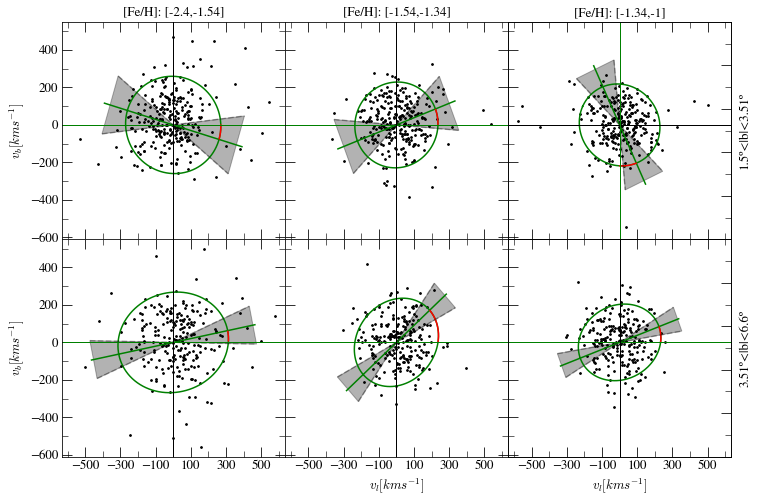

In [3]:
### BMcD 13/09/2024 - This code creates the velocity ellpise of the most metal poor RR Lyrae stars
###                   This can be improved to allow any velocity ellpise to be shown  

from __future__ import division
import pandas as pd
import numpy as np
import math


import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

import functions.compute_variables as CV
from functions.errorconfig import BootstrapConfig, MonteCarloConfig
import functions.montecarlo_errors as montecarlo
import functions.bootstrap_errors as bootstrap

import functions.miscellaneous_functions as MF
import functions.matplotlib_param_funcs as plot_param
import functions.ellipse_functions as EP

import functions.load_data as load_data
import functions.load_RRLyr as load_RRLyr

plot_param.set_matplotlib_params()        
bootstrapconfig = BootstrapConfig(from_mean=False,symmetric=True,repeats=5000)


def equal_number_binning(df, var, min, max, nbins):

    """
    This function takes some data and bins them into n equal-number bins
    e.g. stars to be binned into 4 equal-number bins over 1.4º<|b|<7º would need var"b", min=1.5, max=7, nbins=4

    Parameters
    ----------
    df: pandas dataframe 
    var: variable within df to bin
    min: minimum bin edge
    max: maximum bin edge
    nbins: number of bins

    Returns
    ------
    binned_data: list of length nbins with each element contained the binned data between the corresponding i, i+1 bin edges in bin_edges
    bin_edges: list of length nbins+1 contained the bin edges
    """

    bin_edges = [min] 
    binned_data = []

    data_to_bin = df[(min<=df[var])&(df[var]<=max)] ### get data between min and max variables of the set variable

    goal = round(len(data_to_bin)/nbins) ### find the number of stars each bin should have
    step = 0.001

    # for every bin
    for bin in range(nbins):

        # find the starting bin edge
        lower_edge = bin_edges[bin]

        bin_df = data_to_bin[lower_edge<=data_to_bin[var]]
        equal_cut_test = lower_edge

        # step through the bin range and count the number of stars 
        for pop in range(50000):
                middle_cut = bin_df[bin_df[var]<=equal_cut_test]

                count_test = len(middle_cut)

                if count_test >= goal: ### stop the step if the number of stars in the bin is equal to the same number of stars in all bins
                    break

                if equal_cut_test >= max: ### stop the step if the current bin edge is greater than the maximum edge
                    break

                equal_cut_test += step 

        upper_edge = equal_cut_test ### find the upper edge of the current bin

        bin_edges.append(upper_edge)

        b_bin_stars = bin_df[(lower_edge<=bin_df[var])&(bin_df[var]<+upper_edge)] # get the data between the lower and upper bin edge

        binned_data.append(b_bin_stars)

    return binned_data, bin_edges



def get_error(df,true_value,function,error_type,vel_x_var=None,vel_y_var=None,montecarloconfig=None,bootstrapconfig=None,tilt=False,absolute=False,R_hat=None):

    if error_type=="MC" and montecarloconfig is None:
        raise ValueError(f"Estimating MC errors but montecarloconfig was None.")
    if error_type=="bootstrap" and bootstrapconfig is None:
        raise ValueError(f"Estimating bootstrap errors but bootstrapconfig was None.")

    if vel_x_var is None and vel_y_var is None:
        raise ValueError("At least one of vel_x_var and vel_y_var must not be None.")

    if error_type == "bootstrap":

        vx,vy = None,None

        if vel_x_var is not None:
            vx = df["v"+vel_x_var].values
        if vel_y_var is not None:
            vy = df["v"+vel_y_var].values
        
        result = bootstrap.get_std_bootstrap(function=function, vx=vx, vy=vy, tilt=tilt, absolute=absolute, R_hat=R_hat,config=bootstrapconfig)

        return result.confidence_interval
    
    elif error_type == "MC":
        std_low,std_high,*_ = montecarlo.get_std_MC(df=df, true_value=true_value,function=function, montecarloconfig=montecarloconfig, vel_x_var=vel_x_var, vel_y_var=vel_y_var, \
                                         tilt=tilt, absolute=absolute, R_hat=R_hat)
        
        return std_low,std_high
    
    else:
        raise ValueError(f"Error type `{error_type}` not recognised.")

# slight changes have been amde to this function from Luismi's version
# although I am using dictionaries, I am not using them in the way Luismi has
# The function works to check if "full_map_string_list" is a calculation to be done, if so it shall calculate it along with its error
def get_all_variable_values_and_errors(df_vals,vel_x_var,vel_y_var,full_map_string_list,df_errors=None,montecarloconfig=None,bootstrapconfig=bootstrapconfig,\
                                       min_number=0, bin_surface=None, R_hat=None, x_var=None,y_var=None,error_type="bootstrap", lower=False, upper=False):
    
    """
    Create a dictionary with the values of all the variables in full_map_string_list.

    Parameters
    ----------
    df_vals : pandas DataFrame
        Data, observational or simulated, to compute the variables for.
    vel_x_var : str
        Suffix of x-component of velocity.
    vel_y_var : str
        Suffix of y-component of velocity.
    full_map_string_list : list of str
        List of statistics to compute (e.g., 'mean_vx', 'std_vx', 'n_density').
    df_errors : pandas DataFrame, optional
        Data previous to applying any cuts that affect the Monte Carlo error calculation.
        Defaults to None, in which case df_vals is used.
    montecarloconfig : MonteCarloConfig, optional
        Configuration for Monte Carlo error estimation. See src/errorconfig.py
        Required if error_type is 'MC'. Defaults to None.
    bootstrapconfig : BootstrapConfig, optional
        Configuration for bootstrap error estimation. See src/errorconfig.py
        Required if error_type is 'bootstrap'. Defaults to None.
    min_number : int, optional
        Minimum number of stars required to compute statistics. Defaults to 50.
    bin_surface : float, optional
        Surface area of each bin, required to calculate the number density. 
        Required if 'n_density' is in full_map_string_list. Defaults to None.
    R_hat : tuple, optional
        Radial distance, required for spherical tilt calculations. Defaults to None.
    x_var : str, optional
        Horizontal position variable, required for spherical tilt calculations. Defaults to None.
    y_var : str, optional
        Vertical position variable, required for spherical tilt calculations. Defaults to None.
    error_type : str, optional
        Type of error estimation to use ('bootstrap' or 'MC'). Defaults to 'bootstrap'.

    Returns
    -------
    map_dict : dict
        A dictionary with the values of all the variables in full_map_string_list.
    """
    
    if "spherical_tilt" in full_map_string_list and (x_var is None or y_var is None or R_hat is None):
        raise ValueError("Cannot compute spherical_tilt without R_hat, x_var and y_var.")
    if "n_density" in full_map_string_list and not bin_surface:
        raise ValueError("Cannot compute n_density without bin_surface.")
    if error_type == "MC":
        if montecarloconfig is None:
            raise ValueError("The MC config needs to be passed when error_type is MC, but it was None.")
        elif df_errors is None:
            raise ValueError("df_errors needs to be passed when error_type is MC, but it was None.")
        elif len(df_errors) == len(df_vals) and np.all(df_errors == df_vals): # need the length check otherwise element-to-element comparison fails
            print("The dataframe for values and errors were identical.")
    elif error_type == "bootstrap":
        if bootstrapconfig is None:
            raise ValueError("The bootstrap config needs to be passed when error_type is bootstrap, but it was None.")
    if error_type != "MC" and df_errors is not None and np.any(df_errors != df_vals):
        raise ValueError(f"The dataframe for values and errors should be the same when estimating the latter using `{error_type}`.")

    if df_errors is None:
        df_errors = df_vals

    vx,vy = df_vals["v"+vel_x_var].values, df_vals["v"+vel_y_var].values

    map_dict = {}

    number = len(vx)

    if "number" in full_map_string_list:
        map_dict["number"] = number
    
    if "n_density" in full_map_string_list:
        n_density = number/bin_surface
        map_dict["n_density"] = n_density
    
    if number < min_number:
        print(f"Found `{number}` stars, less than the min of `{min_number}`")
        for variable in full_map_string_list:
            if variable != "number" and variable != "n_density":
                map_dict[variable] = np.nan 
        return map_dict

    common_error_args = {
        "df": df_errors,
        "error_type": error_type,
        "montecarloconfig": montecarloconfig,
        "bootstrapconfig": bootstrapconfig
    }
    
    if full_map_string_list == "mean_vx":
        calc = np.mean(vx)
        low, high = get_error(true_value=None,function=np.mean,vel_x_var=vel_x_var,**common_error_args)
    
    if full_map_string_list == "mean_vy":
        calc = np.mean(vy)
        low, high = get_error(true_value=None,function=np.mean,vel_y_var=vel_y_var,**common_error_args)

    if full_map_string_list == "std_vx":
        calc = np.std(vx)
        low, high = get_error(true_value=None,function=np.std,vel_x_var=vel_x_var,**common_error_args)

    if full_map_string_list == "std_vy":
        calc = np.std(vy)
        low, high = get_error(true_value=None,function=np.std,vel_y_var=vel_y_var,**common_error_args)
    
    if full_map_string_list == 'anisotropy':
        calc = CV.calculate_anisotropy(vx=vx,vy=vy)
        low, high = get_error(true_value=None,function=CV.calculate_anisotropy,vel_x_var=vel_x_var,vel_y_var=vel_y_var,**common_error_args)


    if  full_map_string_list == "correlation":
        calc = CV.calculate_correlation(vx=vx,vy=vy)
        low, high = get_error(true_value=None,function=CV.calculate_correlation,vel_x_var=vel_x_var,vel_y_var=vel_y_var,**common_error_args)
    
    if full_map_string_list == "tilt_abs":
        calc = CV.calculate_tilt(vx=vx,vy=vy,absolute=True)
        low, high = get_error(true_value=None,function=CV.calculate_tilt,vel_x_var=vel_x_var,vel_y_var=vel_y_var,tilt=True,absolute=True,**common_error_args)
    
    if "spherical_tilt" in full_map_string_list:
        vx_s,vy_s = df_vals["v"+x_var].values, df_vals["v"+y_var].values

        map_dict["spherical_tilt"] = CV.calculate_spherical_tilt(vx_s,vy_s,R_hat,absolute=False)
        map_dict["spherical_tilt_error_low"],map_dict["spherical_tilt_error_high"] =\
              get_error(true_value=map_dict["spherical_tilt"],function=CV.calculate_spherical_tilt,vel_x_var=x_var,vel_y_var=y_var,tilt=True,absolute=False,R_hat=R_hat, **common_error_args)

    if "abs_spherical_tilt" in full_map_string_list:
        map_dict["abs_spherical_tilt"] = abs(map_dict["spherical_tilt"])
        map_dict["abs_spherical_tilt_error_low"],map_dict["abs_spherical_tilt_error_high"] =\
              get_error(true_value=map_dict["abs_spherical_tilt"],function=CV.calculate_spherical_tilt,vel_x_var=x_var,vel_y_var=y_var,absolute=True,R_hat=R_hat, **common_error_args)

    if "tilt" in full_map_string_list:
        map_dict["tilt"] = CV.calculate_tilt(vx=vx,vy=vy,absolute=False)
        map_dict["tilt_error"] = get_error(true_value=map_dict["tilt"],function=CV.calculate_tilt, vel_x_var=vel_x_var,vel_y_var=vel_y_var, tilt=True,absolute=False, **common_error_args)        

    return calc, low, high


def compute_correlation(df, vx, vy):
    return CV.calculate_correlation(df[vx].values,df[vy].values)

'''
def compute_anisotropy(df, vx, vy):
    return CV.calculate_anisotropy(df[vx].values,df[vy].values)


def compute_tilt_abs(df, vx, vy):
    return CV.calculate_tilt(df[vx].values,df[vy].values,absolute=True)
'''

def rotate(point, angle):
    """
    Rotate a point counterclockwise by a given angle around the origin.

    The angle should be given in radians.
    """
    px, py = point

    qx = math.cos(angle) * (px) - math.sin(angle) * (py)
    qy = math.sin(angle) * (px) + math.cos(angle) * (py)
    return qx, qy



R0 = 8.1
Z0 = 0
obs_errors = False
GSR=True
zabs = True 

############################################## Read in data ############################################## 

print('############################################## Read in data ############################################## ')

print('Load RRLyr')
RRLyr_data = load_RRLyr.load_RRLyr_data('../data/RRLyr-6D.csv')
print('\n')
print('Load APOGEE')
APOGEE_d = load_data.load_and_process_data(data_path='../../data/observations/', error_bool=obs_errors, zabs=zabs, R0=R0, GSR=GSR)

print('\n')

############################################## Spatial Cuts ############################################## 

print('############################################## Spatial Cuts ############################################## ')

# set spatial cuts 
x_variable = "l"
y_variable = "b"

extra_variable = "R"

xmin = -2
xmax = 2

ymin = 1.5
ymax = 13

dmin=5
dmax=11

extra_min = 0
extra_max = 3.5

xymax = 3.5
zmax = 3

# metallciity cuts - takes RR Lyrae stars of [Fe/H]=[-2.5, -1] and APOGEEstars of [Fe/H]=[-1.5, inf)
RRLyr_spatial = RRLyr_data[(RRLyr_data[x_variable]>=xmin)&(RRLyr_data[x_variable]<=xmax)&(RRLyr_data[y_variable]>=ymin)&(RRLyr_data[y_variable]<=ymax)&(RRLyr_data[extra_variable]>=extra_min)&(RRLyr_data[extra_variable]<extra_max)&(-2.5<=RRLyr_data['FeH'])&(RRLyr_data['FeH']<=-1)]

APOGEE_spatial = APOGEE_d[(APOGEE_d[x_variable]>=xmin)&(APOGEE_d[x_variable]<=xmax)&(APOGEE_d[y_variable]>=ymin)&(APOGEE_d[y_variable]<=ymax)&(APOGEE_d[extra_variable]>=extra_min)&(APOGEE_d[extra_variable]<extra_max)&(-1.5<=APOGEE_d['FeH'])]

print('\n')

############################################## Binning ############################################## 

print('############################################## Binning ##############################################')


latitude = [ymin, 3.51, 6.6, 7.13, 8.85, 11, 13]

# using dictionaries to keep the APOGEE and RR Lyrae datasets seperate
dataset_dict = {'APOGEE': APOGEE_spatial,
                 'RRLyr': RRLyr_spatial
                 }

lat_data_dict = {

    'APOGEE': {},
    'RRLyr': {}

}

metal_data_dict = {

    'APOGEE': {},
    'RRLyr': {}

}

metal_edge_dict = {

    'APOGEE': {},
    'RRLyr': {}

}

labels = [str(ymin)+'º<|b|<'+str(3.51)+'º', str(3.51)+'º<|b|<'+str(6.6)+'º', str(7.13)+'º<|b|<'+str(8.85)+'º', str(11)+'º<|b|<'+str(13)+'º']

div_num = [4, 4, 3, 3]

step = 0.001

metal_bins = []
metal_bin_edges = []

for dataset in dataset_dict:

    print(dataset)

    # as we are not making a bin between each latitude edge (e.g. we only want [3.51, 6.6], [7.13, 8.85] and not [6.6, 7.13])
    for lat in range(len(latitude)-3): 

        lower = latitude[lat]
        upper = latitude[lat+1]

        if lat == 2:
            lower = 7.13
            upper = 8.85

        if lat == 3:
            lower = 11
            upper = 13
        
        lat_data = dataset_dict[dataset][(lower<=dataset_dict[dataset][y_variable])&(dataset_dict[dataset][y_variable]<=upper)] ### get data in latitude bin

        metal_min = lat_data['FeH'].min()
        metal_max = lat_data['FeH'].max()
        
        # each latitude will have a set of metallicity bins, to keep the latitude bins seperate we create a dictionary for each latitude
        # e.g. the metallicity bins in the 1.5º<|b|<3.51º latitude bin will be in the 1.5º<|b|<3.51º dictionary 
        metal_data_dict[dataset].update({labels[lat]:{}})
        metal_edge_dict[dataset].update({labels[lat]:{}})

        # keep the RR Lyrae data to three metallicity bins
        if dataset == 'RRLyr':
            d_num=3
        else:
            d_num = div_num[lat]

        # bin latitude data into equal number metallicity bins
        equal_bin_data, equal_metal_edges = equal_number_binning(df=lat_data, var='FeH', min=metal_min, max=metal_max, nbins=d_num) 

        print(labels[lat])
        #print(equal_metal_edges)

        # for each metallicity bin update the data dictionary and edge dictionary
        metal_data_dict[dataset].update({labels[lat]:equal_bin_data})
        metal_edge_dict[dataset].update({labels[lat]:equal_metal_edges})

print('\n')

############################################## Ellipse PLot ############################################## 

print('############################################## Ellipse Plot ##############################################')

vel_x_var='l'
vel_y_var='b'

vx,vy = "v"+vel_x_var, "v"+vel_y_var

fig, ax = plt.subplots(nrows=2, ncols=len(metal_data_dict['RRLyr']['3.51º<|b|<6.6º']), constrained_layout=True, sharey=True, sharex=True)

for lat_ind, lat in enumerate(metal_data_dict['RRLyr']):

    if lat_ind == 2:
        break

    clr_ind = 150
    
    for metal_ind,metal in enumerate(metal_data_dict['RRLyr'][lat]):

        # finds the metallicity title for each subplot
        low = MF.return_int_or_dec(metal_edge_dict['RRLyr'][lat][metal_ind], 2)
        high = MF.return_int_or_dec(metal_edge_dict['RRLyr'][lat][metal_ind+1], 2)
        
        # calculates the tilt and correlation of the velocity ellipse
        tilt, tilt_err_low, tilt_err_high = get_all_variable_values_and_errors(df_vals=metal, vel_x_var=vel_x_var, vel_y_var=vel_y_var, full_map_string_list='tilt_abs',
         error_type='bootstrap', bootstrapconfig=bootstrapconfig)
        corr, corr_err_low, corr_err_high = get_all_variable_values_and_errors(df_vals=metal, vel_x_var=vel_x_var, vel_y_var=vel_y_var, full_map_string_list='correlation',
         error_type='bootstrap', bootstrapconfig=bootstrapconfig)

        # finds the x and y coordinates for the ellpise and its semi major axies
        std_vx = np.std(metal[vx])
        std_vy = np.std(metal[vy])
        covxy = corr*std_vx*std_vy
        ep_x, ep_y = EP.get_vel_ellipse_coords(std_vx*std_vx, std_vy*std_vy, covxy)#, 1.5)
        max_vector = EP.get_max_vector_from_moments(std_vx*std_vx, std_vy*std_vy, covxy)
        vector_plot_data = np.array([[max_vector[0], -max_vector[0]],[max_vector[1], -max_vector[1]]])
        vector_plot_data_for_angle = np.array([[max_vector[0], -max_vector[0]],[max_vector[1], -max_vector[1]]])/1.5
        r_hat_x = np.linspace(vector_plot_data[0][1], vector_plot_data[0][0], len(ep_x))
        r_hat_y = np.linspace(vector_plot_data[1][1], vector_plot_data[1][0], len(ep_x))

        # rotates the semi major axies by the low and high error of the vertex deviation (to visulaise the error in vertex deviation)
        low_test_x, low_test_y = rotate((r_hat_x, r_hat_y), np.radians(tilt_err_low))
        high_test_x, high_test_y = rotate((r_hat_x, r_hat_y), np.radians(-tilt_err_high))

        # sets which axes to highlight to visulaise what axes hte vertex deviation is being measured from
        if std_vx**2 > std_vy**2:
            axes = 'horizontal'
        elif std_vx**2 < std_vy**2:
            axes = "vertical"

        # creates a dataframe for the x and y coordinates of the ellpise
        d_ep = {'x':ep_x, 'y':ep_y}
        df_ep = pd.DataFrame(data=d_ep)

        # creates a dataframe for the x and y coordinates fo the semi-major axis of the ellpise  
        d_r_hat = {'x':r_hat_x, 'y':r_hat_y}
        df_r_hat = pd.DataFrame(data=d_r_hat)

        # finds the correct quadrant for the vertex deviation to be measured in
        if axes == 'horizontal':
            if tilt > 0:
                condition_ep = (df_ep.y>=0)&(df_ep.x>=0)
                condition_r_hat = (df_r_hat.y>=0)&(df_r_hat.x>=0)
            if tilt < 0:
                condition_ep = (df_ep.y<=0)&(df_ep.x>=0)
                condition_r_hat = (df_r_hat.y<=0)&(df_r_hat.x>=0)
        elif axes == 'vertical':
            if tilt > 0:
                condition_ep = (df_ep.y<=0)&(df_ep.x<=0)
                condition_r_hat = (df_r_hat.y<=0)&(df_r_hat.x<=0)
            if tilt < 0:
                condition_ep = (df_ep.y<=0)&(df_ep.x>=0)
                condition_r_hat = (df_r_hat.y<=0)&(df_r_hat.x>=0)
        df_ep = df_ep[condition_ep] ### limits the ellpise coordinates for the right quadrant


        # finds the correct side of the semi-major axis to measure the vertex deviation to
        for star in zip(df_ep['x'], df_ep['y']):
            for r_hat in zip(df_r_hat['x'], df_r_hat['y']):
                if r_hat[0]-4<=star[0]<=r_hat[0]+4 and r_hat[1]-4<=star[1]<=r_hat[1]+4:
                            if axes == 'horizontal':
                                r_hat_bound = r_hat[1]
                            elif axes == 'vertical':
                                r_hat_bound = r_hat[0]
        

        # finds the x and y coordiantes of the ellpise that is in the angle of the vertex deviation
        if axes == 'horizontal':
            if tilt > 0:
                angle_condition = (df_ep['y']<= r_hat_bound)
            elif tilt < 0:
                 angle_condition = (df_ep['y']>= r_hat_bound)
        if axes == 'vertical':
            if tilt > 0:
                angle_condition = (df_ep['x']>= r_hat_bound)
            elif tilt < 0:
                 angle_condition = (df_ep['x']<= r_hat_bound)
        df_ep = df_ep[angle_condition] ### limits the coordaintes to the ellpise within the vertex deviation   
    
        # PLotting
        ax[lat_ind, metal_ind].scatter(metal['vr'], metal['vl'], color='k', s=3, label='[Fe/H]: ['+str(low)+','+str(high)+']') ### stars velocity
        ax[lat_ind, metal_ind].plot(ep_x, ep_y, ls='-', c='g') ### velocity ellpise
        ax[lat_ind, metal_ind].plot(r_hat_x, r_hat_y, c='green') ### semi-major axis of the velocity ellipse
        ax[lat_ind, metal_ind].plot(df_ep['x'], df_ep['y'], ls='-', c='red') ### velocity ellipse within the vertex deviaiton
 
        # error on vertex deviation
        ax[lat_ind, metal_ind].plot(low_test_x, low_test_y, ls='--', c='k', label='low', alpha=0.3)
        ax[lat_ind, metal_ind].plot(high_test_x, high_test_y, ls='--', c='k', label='high', alpha=0.3)
        ax[lat_ind, metal_ind].fill(np.append(low_test_x, high_test_x[::-1]),np.append(low_test_y, high_test_y[::-1]), c='k', alpha=0.3)

        # x, y = 0 lines to highlight the angle of the vertex deviation
        ax[lat_ind, metal_ind].axhline(0, ls='-', c='g' if axes == 'horizontal' else 'k', lw=1)
        ax[lat_ind, metal_ind].axvline(0, ls='-', c='g' if axes == 'vertical' else 'k', lw=1)

        # velocity labels
        if metal_ind == 0:
            ax[lat_ind, metal_ind].set_ylabel(r'$v_'+vel_y_var+' [kms^{-1}]$')
        elif lat_ind == 1:
            ax[lat_ind, metal_ind].set_xlabel(r'$v_'+vel_x_var+' [kms^{-1}]$')

        # metallicity labels
        if lat_ind == 0:
            ax[lat_ind, metal_ind].set_title('[Fe/H]: ['+str(low)+','+str(high)+']')

        ax[lat_ind, metal_ind].set_xticks(np.arange(-500, 700, 200))
        ax[lat_ind, metal_ind].set_yticks(np.arange(-600, 500, 200))
        ax[lat_ind, metal_ind].xaxis.set_minor_locator(MultipleLocator(100))
        ax[lat_ind, metal_ind].yaxis.set_minor_locator(MultipleLocator(100))

    # latitude labels
    ax2 = ax[lat_ind, 2].twinx()
    ax2.set_ylabel(lat)
    ax2.set_yticklabels([])
    ax2.set_yticks(np.arange(-600, 500, 200))
    ax2.yaxis.set_minor_locator(MultipleLocator(100))
        
    print('\n')


plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig('velocity_ellipse/plots/velocity_ellipse_'+vel_x_var+vel_y_var+'.pdf')
plt.show()